In [4]:
import numpy as np
import pylab as plt
import scipy.stats
from tqdm.notebook import tqdm
plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams['font.size'] = 15

In [5]:
def littlef(chi):
    return ((1+(1-chi**2)**0.5)/2)**0.5



<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_810/4141229162.py:4: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi$')


Text(0, 0.5, '$f$')

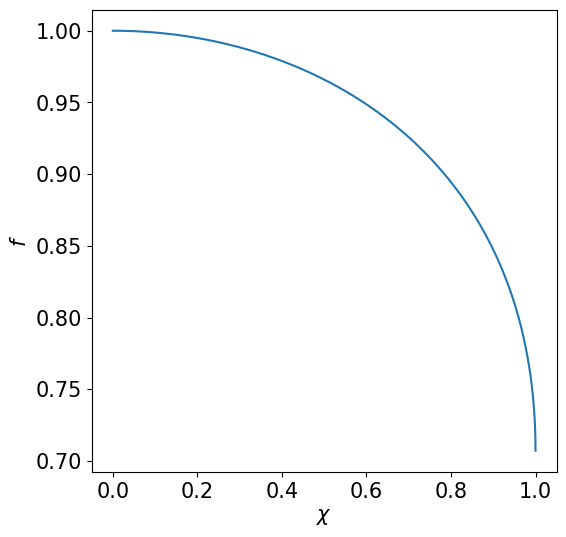

In [6]:
N = 10000
chi = np.linspace(0,1,N)
plt.plot(chi, littlef(chi));
plt.xlabel('$\chi$')
plt.ylabel('$f$')

Text(0.5, 0, '$f$')

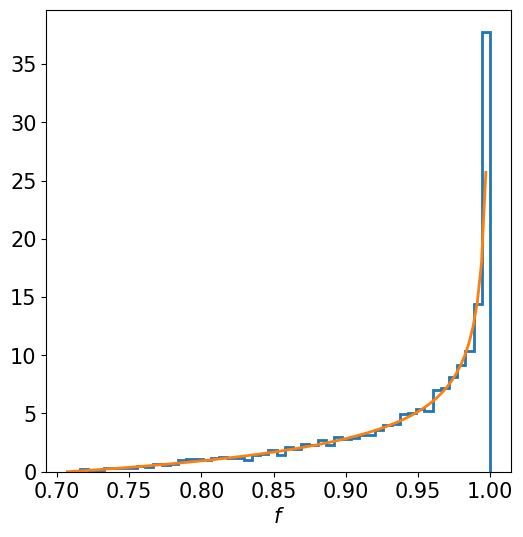

In [7]:
#numerically built f, sample by sample from chi
chi = np.random.uniform(0,1,N)[:-1]
f = littlef(chi)
plt.hist(f, density=True, bins=50, histtype='step', lw=2);

#analytical result
f = np.linspace(1/2**0.5,1,100)[:-1]
pdff = 2*(2*f**2-1)/(1-f**2)**0.5
plt.plot(f,pdff,lw=2);

plt.xlabel('$f$')

Text(0.5, 0, '$M$')

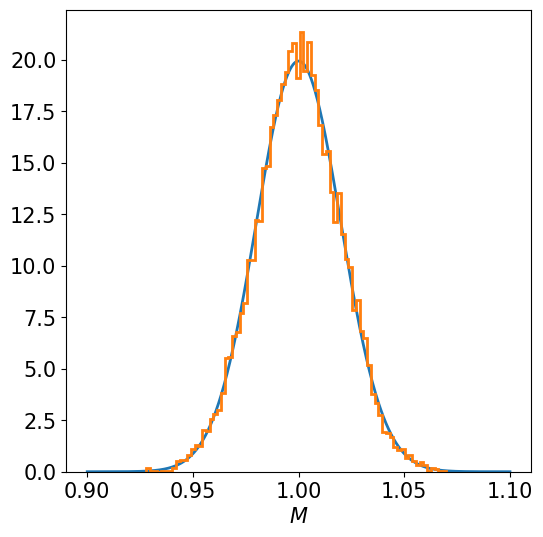

In [8]:
#the mass is gaussian
scale = 0.02

x = np.linspace(1-5*scale,1+5*scale,N)
M = scipy.stats.norm.pdf(x,1,scale)
plt.plot(x,M,lw=2)

M = np.random.normal(loc=1, scale=scale, size=N)
plt.hist(M,density=True, histtype='step',bins=80,lw=2);
         
plt.xlabel('$M$')

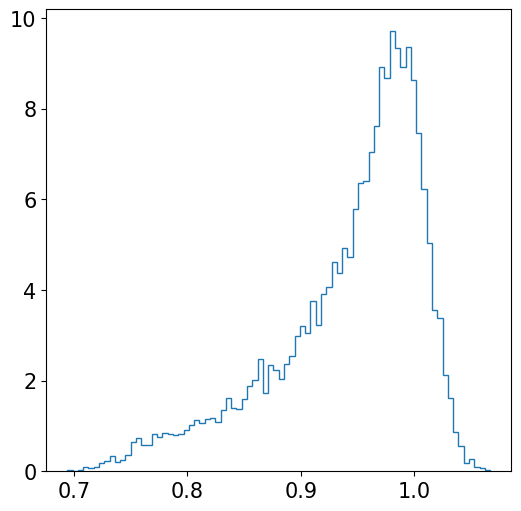

In [9]:
# irriducible mass
chi = np.random.uniform(0,1,N)
m = littlef(chi)
plt.hist(M*m, density=True, histtype='step', bins=80);

In [10]:
# check against the analytic result
chi = np.random.uniform(0,1,N)
m = littlef(chi)

  0%|          | 0/10000 [00:00<?, ?it/s]

Text(0.5, 0, '$M_{\\rm irr}$')

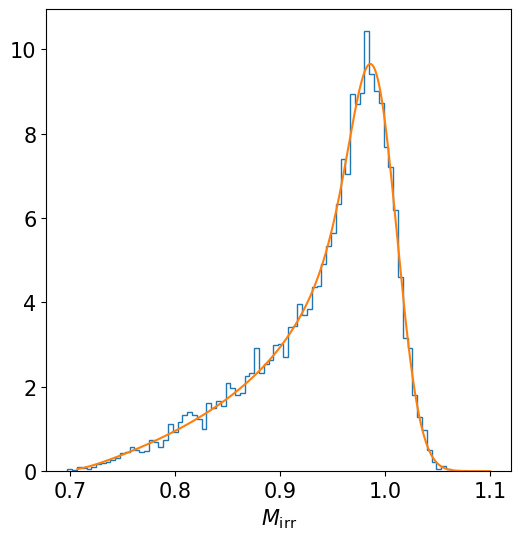

In [13]:
plt.hist(M*m, density=True,histtype='step', bins=80);

x = np.linspace(1/np.sqrt(2), 1+5*scale,N)

def integrand(f,x):
    return((2/np.pi)**0.5 / scale ) * np.exp(-(x/f -1)**2 /(2*scale**2)) * (2*f**2-1)/(1 - f**2)**0.5/f

Mirr = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

plt.plot(x,Mirr)
plt.xlabel('$M_{\\rm irr}$')

In [20]:
# now change the sigma

def plot_M_Mirr(scale):
    
    x = np.linspace(1-5*scale,1+5*scale,N)
    M = scipy.stats.norm.pdf(x,1,scale)
    
    M = np.random.normal(loc=1,scale=scale,size=N)
    
    chi = np.random.uniform(0,1,N)
    m = littlef(chi)
    
    plt.hist(M*m,density=True,histtype='step',bins=80);
    
    x = np.linspace(min(1-5*scale,1/np.sqrt(2)),1+5*scale,N)
    
    def integrand(f,x):
        return ((2/np.pi)**0.5 / scale ) * np.exp(-(x/f-1)**2/(2*scale**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
    
    Mirr = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]
    
    plt.plot(x,Mirr)
    plt.xlabel('$M_{\\rm irr}$')

  0%|          | 0/10000 [00:00<?, ?it/s]

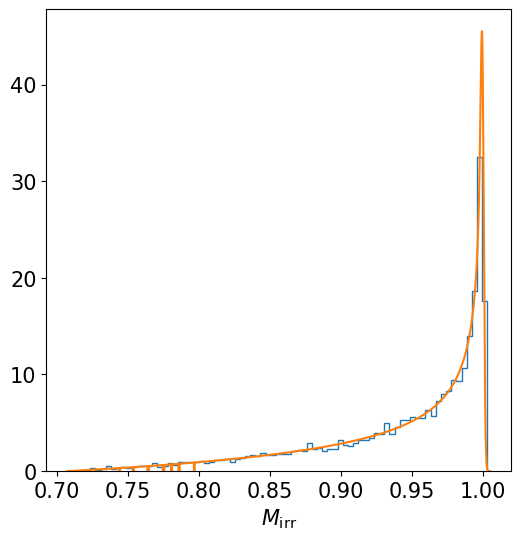

In [21]:
# for small sigmas this looks like the distribution of f
plot_M_Mirr(0.001)

  0%|          | 0/10000 [00:00<?, ?it/s]

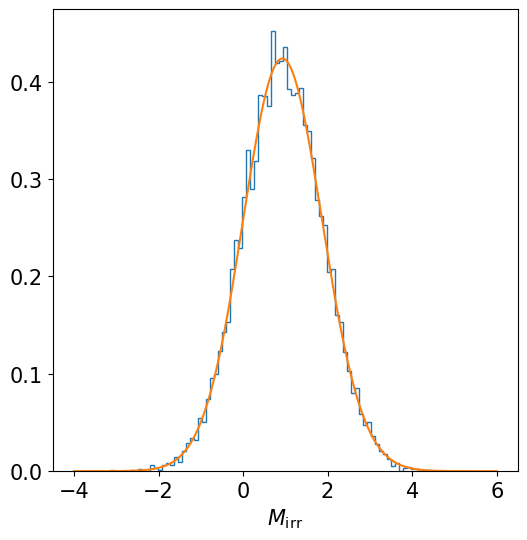

In [22]:
# for large sigmas it looks like the distribution of M
plot_M_Mirr(1)

In [31]:
# chedck this with a KS test
scales = np.logspace(-5,5,20)
ksM = []
ksf = []

N = 100000
chi = np.random.uniform(0,1,N)
f = littlef(chi)
for scale in tqdm(scales):
    M = np.random.normal(loc=1,scale=scale,size=N)
    
    ksM.append(scipy.stats.ks_2samp(M, M*f))
    ksf.append(scipy.stats.ks_2samp(m, M*f))
    
ksM = np.array(ksM)
ksf = np.array(ksf)

  0%|          | 0/20 [00:00<?, ?it/s]

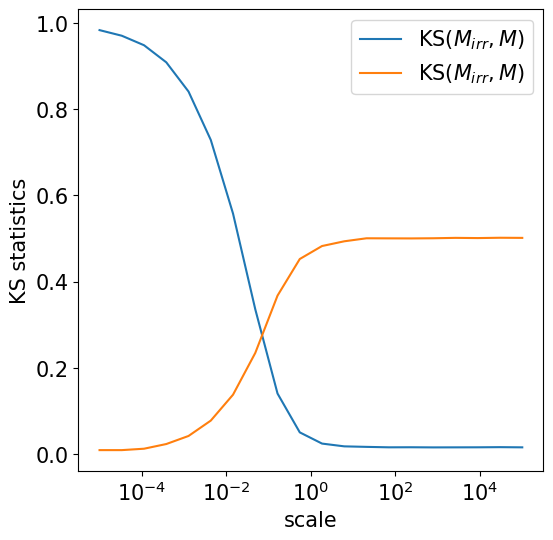

In [33]:
plt.plot(scales,ksM[:,0],label="KS$(M_{irr}, M)$")
plt.plot(scales,ksf[:,0],label="KS$(M_{irr}, M)$")
plt.semilogx()
plt.xlabel("scale")
plt.ylabel('KS statistics')
plt.legend();

# for small sigma, Mirr is distributed like M
# for large sigma, Mirr is distributed like f


In [35]:
# KDE representation
N = 10000

scale = 0.02

x = np.linspace(1-5*scale,1+5*scale,N)
M = scipy.stats.norm.pdf(x,1,scale)
M = np.random.normal(loc=1,scale=scale,size=N)

chi = np.random.uniform(0,1,N)
m = littlef(chi)

x = np.linspace(min(1-5*scale,1/np.sqrt(2)), 1+5*scale,N)

def integrand(f,x):
    return ((2/np.pi)**0.5 / scale ) * np.exp(-(x/f -1)**2 /(2*scale**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f

Mirr = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [37]:
# load the KDE module
from sklearn.neighbors import KernelDensity
xgrid = np.linspace(x.min(),x.max(),N)
    
def kde_sklearn(data,bandwidth = 1.0, kernel='linear'):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel = kernel)
    kde_skl.fit(data[:,np.newaxis])
    log_pdf = kde_skl.score_samples(x[:,np.newaxis])
    
    return np.exp(log_pdf)

  0%|          | 0/3 [00:00<?, ?it/s]

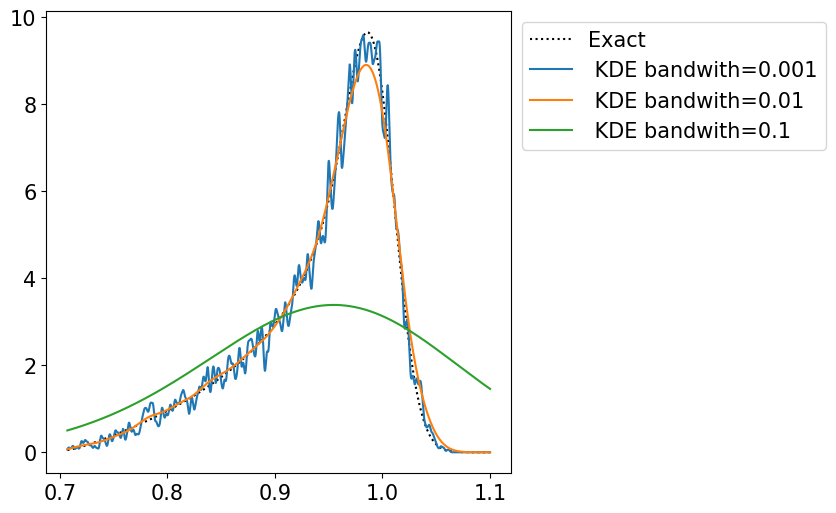

In [38]:
plt.plot(xgrid,Mirr,label='Exact',c='black',ls='dotted')

for bandwith in tqdm([0.001,0.01,0.1]):
    kdepdf = kde_sklearn(M*m,bandwidth=bandwith,kernel="gaussian")

    plt.plot(x,kdepdf,label=' KDE bandwith='+str(bandwith))

plt.legend(bbox_to_anchor=(1,1));